/tmp/ipython-input-1849085069.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax_historisch = yf.download('^GDAXI', start='1990-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed

Starte den Download der DAX-Daten...
Datenaufbereitung fertig. Hier die ersten paar Zeilen:
Price       renditen  verluste
Ticker                        
Date                          
1990-01-03  0.042893 -0.042893
1990-01-04 -0.019670  0.019670
1990-01-05 -0.009891  0.009891
1990-01-08  0.015636 -0.015636
1990-01-09  0.012976 -0.012976

Die schlimmsten Tagesverluste pro Jahr (in %):
Date
1990-12-31    5.25
1991-12-31    9.63
1992-12-31    5.08
1993-12-31    2.53
1994-12-31    2.80
Freq: YE-DEC

Passe die GEV-Verteilung an die Daten an...
Fertig! Die gefundenen GEV-Parameter sind:
Shape (c)    = -0.2315
Location (mu)  = 0.0357
Scale (sigma)  = 0.0138



/tmp/ipython-input-1849085069.py:27: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  schlimmste_jahresverluste = dax_historisch['verluste'].resample('Y').max()


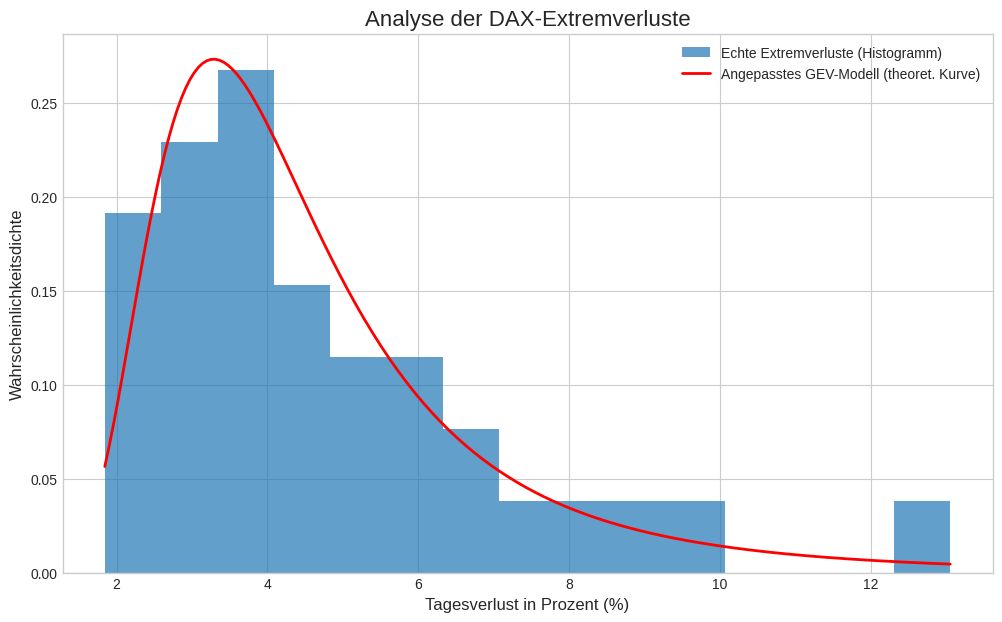


--- Praktische Risikoabschätzung (Return Level) ---
Ein Tagesverlust von 6.04% oder mehr wird statistisch alle 5 Jahre erwartet.
Ein Tagesverlust von 7.64% oder mehr wird statistisch alle 10 Jahre erwartet.
Ein Tagesverlust von 9.47% oder mehr wird statistisch alle 20 Jahre erwartet.
Ein Tagesverlust von 12.32% oder mehr wird statistisch alle 50 Jahre erwartet.

Info: Der schlimmste beobachtete Tagesverlust in den Daten war 13.05%.


In [6]:
#installieren
!pip install yfinance

#importieren
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme #wichtig

#Hauptteil
if __name__ == "__main__":

    #Daten
    print("Starte den Download der DAX-Daten...")
    dax_historisch = yf.download('^GDAXI', start='1990-01-01', end='2024-12-31')

    #Renditen.
    dax_historisch['renditen'] = np.log(dax_historisch['Close'] / dax_historisch['Close'].shift(1))
    dax_historisch['verluste'] = -dax_historisch['renditen']
    dax_historisch.dropna(inplace=True)

    print("Datenaufbereitung fertig. Hier die ersten paar Zeilen:")
    print(dax_historisch[['renditen', 'verluste']].head())

    #Extremwerte (Verluste)
    schlimmste_jahresverluste = dax_historisch['verluste'].resample('Y').max()
    schlimmste_jahresverluste.dropna(inplace=True)

    print("\nDie schlimmsten Tagesverluste pro Jahr (in %):")
    print((schlimmste_jahresverluste.head() * 100).round(2).to_string())

    #Verteilung Anpassen
    print("\nPasse die GEV-Verteilung an die Daten an...")
    c, mu, sigma = genextreme.fit(schlimmste_jahresverluste)

    print(f"Fertig! Die gefundenen GEV-Parameter sind:")
    print(f"Shape (c)    = {c:.4f}")
    print(f"Location (mu)  = {mu:.4f}")
    print(f"Scale (sigma)  = {sigma:.4f}")

    #Plotten
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 7))
    plt.hist(schlimmste_jahresverluste * 100, bins=15, density=True, alpha=0.7, label='Echte Extremverluste (Histogramm)')
    x_achse = np.linspace(schlimmste_jahresverluste.min(), schlimmste_jahresverluste.max(), 200)
    y_achse = genextreme.pdf(x_achse, c=c, loc=mu, scale=sigma)

    #Die rote Linie ist die Modell-Kurve.
    plt.plot(x_achse * 100, y_achse / 100, 'r-', lw=2, label='Angepasstes GEV-Modell (theoret. Kurve)')
    plt.title('Analyse der DAX-Extremverluste', fontsize=16)
    plt.xlabel('Tagesverlust in Prozent (%)', fontsize=12)
    plt.ylabel('Wahrscheinlichkeitsdichte', fontsize=12)
    plt.legend()
    plt.show()

    #Risiko Abschätzen
    print("\n--- Praktische Risikoabschätzung (Return Level) ---")
    jahresintervalle = [5, 10, 20, 50]
    for T in jahresintervalle:
        p = 1 - 1/T
        verlust_level = genextreme.ppf(p, c=c, loc=mu, scale=sigma)

        print(f"Ein Tagesverlust von {(verlust_level * 100):.2f}% oder mehr wird statistisch alle {T} Jahre erwartet.")

    #Vergleich Realität
    schlimmster_tag_jemals = dax_historisch['verluste'].max()
    print(f"\nInfo: Der schlimmste beobachtete Tagesverlust in den Daten war {(schlimmster_tag_jemals*100):.2f}%.")